# Approach


**Intro**


The aim of this assignment is to classify cells as either cancerous or non-cancerous and to identify their cell type using supervised machine learning techniques. There are multiple viable methods for image classification, including Convolutional Neural Networks (CNNs), Vision Transformers (ViTs), and Support Vector Machines (SVMs).


Vision Transformers are highly effective at capturing global features within an image. They perform best with large datasets and high-resolution images. ViTs are end-to-end models that handle both feature learning and classification, eliminating the need for manual feature extraction. However, they tend to underperform when training data is limited.


Support Vector Machines can also perform well in image classification tasks, particularly on smaller datasets and for binary classification problems. However, they require manual feature extraction, which adds complexity and can be a barrier if not using pre-trained models.


Convolutional Neural Networks, on the other hand, strike a balance. CNNs work well across a range of dataset sizes, are fully end-to-end, and are widely supported with established architectures. They specialize in learning local patterns within images. A key limitation of CNNs is their reduced ability to capture global context, as they mainly focus on spatially local features.


**EDA**



The dataset contains a total of 9,896 images, making it medium in size. There are no missing or corrupted entries. Each image is 27x27 pixels and clearly shows a single cell, centered in the frame, and there is no blur or obstructions.


The "is cancerous" label is fairly well-balanced, with approximately a 3:2 ratio of non-cancerous to cancerous cells. The "cell type" labels are more imbalanced, with ratios of roughly 8:3 ratio of type 2 cells to 3 cells, and 4:2 ratio of type 2 to type 0 cells. Such imbalances can negatively impact model performance, leading to overfitting or underrepresentation of less frequent classes.

The images themselves are clear and do not require preprossessing. augmentation to reduce class imbalance could be used, however class weighting will likely solve any issues as the class imbalance is not too high

**Sample images**

Fibroblast cell


In [85]:
from IPython.display import Image, display

display(Image(filename='Image_classification_data/patch_images/22415.png',  width=270, height=270)) 


Inflamitory cell

In [86]:
display(Image(filename='Image_classification_data/patch_images/22417.png',  width=270, height=270)) 


Epithelial cell

In [87]:
display(Image(filename='Image_classification_data/patch_images/285.png',  width=270, height=270)) 


Other Cell

In [88]:
display(Image(filename='Image_classification_data/patch_images/19063.png',  width=270, height=270)) 


**Choice of approach**

CNNs are well-suited to this problem. The images are small and focused on individual cells, meaning local pixel patterns are more important than global image structure. CNNs can also learn both tasks directly from the images without extra preprocessing.

Therefore, CNNs are chosen for both classification tasks.


**Model strategy**

CNNs can be designed with a wide range of architectural, activation, and regularization options. This project starts with a base model for both tasks and expands to explore different configurations. Each variation will be evaluated and compared to the baseline. The best-performing combinations will be used to construct an optimized final model.


**Model setup**


All models share the same preprocessing pipeline, including data augmentation techniques such as random rotation, zooming, stretching, and flipping. These augmentations reduce overfitting by introducing variability and preventing the model from memorizing specific images.


Each model is trained for up to 200 epochs. Class weights are applied during training to address class imbalances. Without them, minority classes could be overlooked by the model.


Dropout is set at 0.5 across all models. This means that 50% of the neurons are randomly dropped during training, helping prevent overfitting by reducing the model's reliance on individual neurons.


The baseline model for the "is cancerous" task uses two VGG-style convolutional blocks with ReLU activations and a final sigmoid output layer. A performance metric of accuracy was selected as it is imperative that the model is correct most of the time in identifying cancer.


The baseline model for the "cell type" task uses the same structure but ends with a softmax output layer to support multi-class classification. A performance metric of catagorical accuracy was chosen to maximise the amount of correct classifications.


ReLU is chosen as the default activation due to its widespread usage and solid performance. The choice of two VGG blocks is based on the small input size — larger architectures might not be necessary or effective for 27x27 images.


**Data leakage**

The datasets contain patient based medical data in the form of images of thier cells and ID numbers. It is imperative that this data is correctly handled. To minimise risks of leaks, the ID should not be split into the model. safe and encrypted storage of all data could be used to further keep patient information confidential.

**Generalizability**
generalizability was ensured by training on small subsets of the data each epoch. this ensured the models where robust as the model does not encounter the same data each time. data augmentation further increases generalizeability as it diversifies the data going into the model. finaly the models where tested on a final test set that they had never encountered before to ensure it would work with new data

**Modifications to base models and parameter tuning**


Activation functions


1. ELU – Similar to ReLU but with smoother gradients. May accelerate training.


2. PReLU – A parametric version of ReLU where the slope is learnable. Could enhance accuracy.


3. Swish – Smooth, nonlinear, and resembles ReLU. Helps mitigate the “dying ReLU” issue by allowing small negative values.


Structure


1. 3 layers - Increases depth to allow more complex features to be learned.
2. Simplified layers - Reduces the number of pooling layers to speed up training without losing too much information.
4. l2 regularisation - Penalizes large weights to prevent the model from overfitting to specific features. Regularization strength (λ) is set to 0.001.
3. Early stopping - Stops training when the model performance stops improving, which helps avoid overfitting and reduces wasted training time.


**Transfer Learning Approach**

A final cell type model will be built by first pretraining a model on the “is cancerous” task using the extra dataset. Once trained, the model will be restructured and retrained to predict cell types using the main dataset. This transfer learning approach allows the model to leverage features learned from a larger dataset, potentially improving its final accuracy.


**Initialisation, data pre proccessing and class weights**

In [60]:
import numpy as np
import time
import os as os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, PReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.activations import swish
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report



data_dir = 'Image_classification_data/patch_images'  

dataLabels = pd.read_csv('Image_classification_data/data_labels_mainData.csv')
dataLabels['isCancerous'] = dataLabels['isCancerous'].astype(str)

img_size = (27, 27)
batch_size = 32

train_data, test_data = train_test_split(dataLabels, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.25, random_state=42)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0.001,
    restore_best_weights=True
)

isCancerous_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(dataLabels['isCancerous']),
    y=dataLabels['isCancerous']
)

isCancerous_class_weights_dict = dict(enumerate(isCancerous_class_weights))

cellType_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(dataLabels['cellTypeName']),
    y=dataLabels['cellTypeName']
)

cellType_class_weights_dict = dict(enumerate(cellType_class_weights))

print(dataLabels['isCancerous'].value_counts())
print(dataLabels['cellTypeName'].value_counts())

isCancerous
0    5817
1    4079
Name: count, dtype: int64
cellTypeName
epithelial      4079
inflammatory    2543
fibroblast      1888
others          1386
Name: count, dtype: int64


**Datagen and splitting**

The data is split into 3 sets, train, test and validation, with the dataset first being split into train and test splits, with %80 of the data going to train. The data is then further split into train and validation sets, with %75 going to train. The train and validation sets are used to tune the model, with the test set being used to get the final performance score of the model. This ensures that whenever the models performance is being measured its measured on data its never seen before

In [61]:
isCancerous_train_data = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName', 
    y_col='isCancerous',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False 
)

isCancerous_val_data = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName',  
    y_col='isCancerous',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False 
)

isCancerous_test_data = val_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName',  
    y_col='isCancerous',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False 
)

Found 5937 validated image filenames belonging to 2 classes.
Found 1979 validated image filenames belonging to 2 classes.
Found 1980 validated image filenames belonging to 2 classes.


In [62]:

cellType_train_data = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName', 
    y_col='cellTypeName',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False 
)


cellType_val_data = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName',  
    y_col='cellTypeName',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False 
)

cellType_test_data = val_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName',  
    y_col='cellTypeName',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False 
)

Found 5937 validated image filenames belonging to 4 classes.
Found 1979 validated image filenames belonging to 4 classes.
Found 1980 validated image filenames belonging to 4 classes.


# Models

# Is cancerous

**Base**

In [63]:
isCancerousModel_base = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)), 
    Conv2D(32, (3, 3), activation='relu', padding='same'), 
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

/home/leo/cancerAI/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Activation**

In [64]:
isCancerousModel_elu = Sequential([
    Conv2D(32, (3, 3), activation='elu', padding='same', input_shape=(27, 27, 3)), 
    Conv2D(32, (3, 3), activation='elu', padding='same'), 
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='elu'),
    Conv2D(64, (3, 3), padding='same', activation='elu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='elu'),
    Dense(1, activation='sigmoid') 
])

isCancerousModel_PReLU = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(27, 27, 3)),
    PReLU(alpha_initializer='zeros'),
    
    Conv2D(32, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),

    Conv2D(64, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64),
    PReLU(alpha_initializer='zeros'),
    
    Dense(1, activation='sigmoid')
])

isCancerousModel_swish = Sequential([
    Conv2D(32, (3, 3), activation=swish, padding='same', input_shape=(27, 27, 3)), 
    Conv2D(32, (3, 3), activation=swish, padding='same'), 
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation=swish),
    Conv2D(64, (3, 3), padding='same', activation=swish),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation=swish),
    Dense(1, activation='sigmoid') 
])


**Structure**

In [65]:
reg_lambda = 0.001

isCancerousModel_3Layers = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)), 
    Conv2D(32, (3, 3), activation='relu', padding='same'), 
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') 
])

isCancerousModel_simplifiedLayers = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

isCancerousModel_regularisation = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda), input_shape=(27, 27, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda)),
    Conv2D(64, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda)),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

isCancerousModel_earlyStop = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)), 
    Conv2D(32, (3, 3), activation='relu', padding='same'), 
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

In [66]:
isCancerousModels_activation = {
    "ELU activation": isCancerousModel_elu,
    "PReLU activation": isCancerousModel_PReLU,
    "Swish activation": isCancerousModel_swish,
}


isCancerousModels_structure = {
    "3 Layer": isCancerousModel_3Layers,
    "Simplified layers": isCancerousModel_simplifiedLayers,
    "Regularisation": isCancerousModel_regularisation
}


# Cell Type

**Base**

In [67]:
cellTypeModel_base = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax') 
])

**Activation**

In [68]:
cellTypeModel_swish = Sequential([
    Conv2D(32, (3, 3), activation=swish, padding='same', input_shape=(27, 27, 3)),
    Conv2D(32, (3, 3), activation=swish, padding='same'),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation=swish),
    Conv2D(64, (3, 3), padding='same', activation=swish),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='swish'),
    Dense(4, activation='softmax') 
])

cellTypeModel_elu = Sequential([
    Conv2D(32, (3, 3), activation='elu', padding='same', input_shape=(27, 27, 3)),
    Conv2D(32, (3, 3), activation='elu', padding='same'),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='elu'),
    Conv2D(64, (3, 3), padding='same', activation='elu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='elu'),
    Dense(4, activation='softmax') 
])

cellTypeModel_PReLU = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(27, 27, 3)),
    PReLU(alpha_initializer='zeros'),
    
    Conv2D(32, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),

    Conv2D(64, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64),
    PReLU(alpha_initializer='zeros'),
    
    Dense(4, activation='softmax')
])

**Structure**

In [69]:
cellTypeModel_3Layers = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax') 
])

cellTypeModel_simplifiedLayers = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax') 
])

cellTypeModel_regularisation = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda), input_shape=(27, 27, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda)),
    Conv2D(64, (3, 3), activation='relu', padding='same', 
        kernel_regularizer=tf.keras.regularizers.l2(reg_lambda)),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax') 
])

cellTypeModel_earlyStop = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax') 
])



In [70]:
cellTypeModels_activation = {
    "ELU activation": cellTypeModel_elu,
    "PReLU activation": cellTypeModel_PReLU,
    "Swish activation": cellTypeModel_swish,
}

cellTypeModels_structure = {
    "3 Layer": cellTypeModel_3Layers,
    "Simplified layers": cellTypeModel_simplifiedLayers,
    "Regularisation": cellTypeModel_regularisation,
}

**Training and evaluation functions**

In [71]:
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Accuracy'):
    plt.figure(figsize=(10,5))
    
    plt.subplot(1,2,1)
    plt.plot(train_loss, 'r--')
    plt.plot(val_loss, 'b--')
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.legend(['train', 'val'], loc='upper left')

    plt.subplot(1,2,2)
    plt.plot(train_metric, 'r--')
    plt.plot(val_metric, 'b--')
    plt.xlabel("epochs")
    plt.ylabel(metric_name)
    plt.legend(['train', 'val'], loc='upper left')

    plt.show()

In [72]:
results = []

def train_and_evaluate_model(name, model, train_data, val_data, test_data, loss, metrics, epochs, class_weight=None, earlyStop=None):
    print(f"\nTraining {name} model...\n")
    
    model.compile(optimizer='adam', loss=loss, metrics=metrics)

    start_time = time.time()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=earlyStop,
        class_weight=class_weight,
        verbose=0
    )
    
    total_time = time.time() - start_time
    avg_epoch_time = total_time / len(history.history['loss'])
    num_epochs = len(history.history['loss'])

    losses = []
    accuracies = []

    for i in range(20):
        loss, acc = model.evaluate(test_data, verbose=0)
        losses.append(loss)
        accuracies.append(acc)

    avg_loss = np.mean(losses)
    avg_acc = np.mean(accuracies)

    y_true = test_data.classes
    y_pred = model.predict(test_data, verbose=0)
    
    if model.output_shape[-1] == 1:
        y_pred_labels = (y_pred > 0.5).astype(int).flatten()
    else:
        y_pred_labels = np.argmax(y_pred, axis=1)

    print(classification_report(y_true, y_pred_labels))

    results.append({
        'Model': name,
        'Total Time (s)': round(total_time, 2),
        'Avg Epoch  Time (s)': round(avg_epoch_time, 2),
        'Total Epochs': num_epochs,
        'Accuracy': round(avg_acc, 4),
        'Loss': round(avg_loss, 4),
    })

    metric_key = metrics[0]
    val_metric_key = f'val_{metric_key}'
    metric_label = 'Accuracy' if 'accuracy' in metric_key else metric_key.replace('_', ' ').capitalize()

    plot_learning_curve(
        history.history['loss'],
        history.history['val_loss'],
        history.history.get(metric_key, []),
        history.history.get(val_metric_key, []),
        metric_name=metric_label
    )
    return model, history



# Is cancerous training


Training is cancerous base model...



/home/leo/cancerAI/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1189
           1       0.90      0.93      0.91       791

    accuracy                           0.93      1980
   macro avg       0.93      0.93      0.93      1980
weighted avg       0.93      0.93      0.93      1980



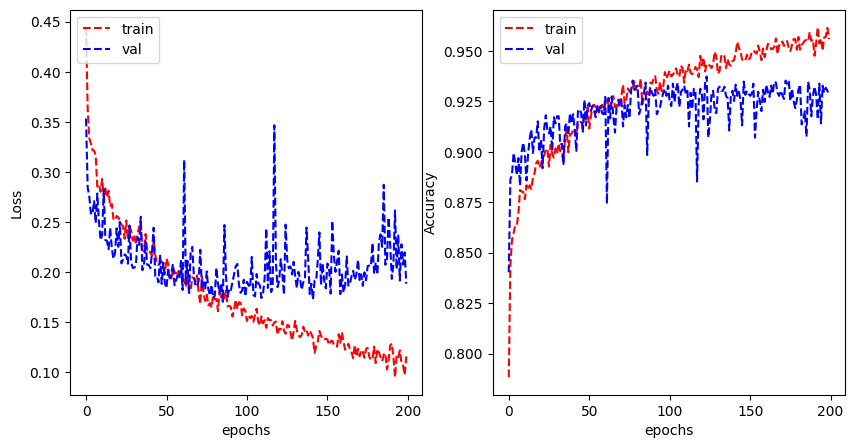

               Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0  is cancerous base         1101.67                 5.51           200   

   Accuracy   Loss  
0    0.9308  0.216  

Training ELU activation model...

              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1189
           1       0.95      0.84      0.89       791

    accuracy                           0.92      1980
   macro avg       0.93      0.91      0.91      1980
weighted avg       0.92      0.92      0.92      1980



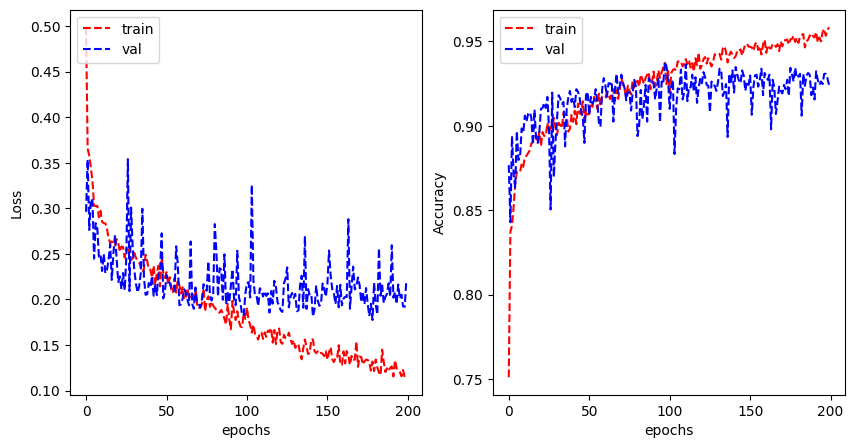


Training PReLU activation model...

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1189
           1       0.94      0.89      0.91       791

    accuracy                           0.93      1980
   macro avg       0.93      0.92      0.93      1980
weighted avg       0.93      0.93      0.93      1980



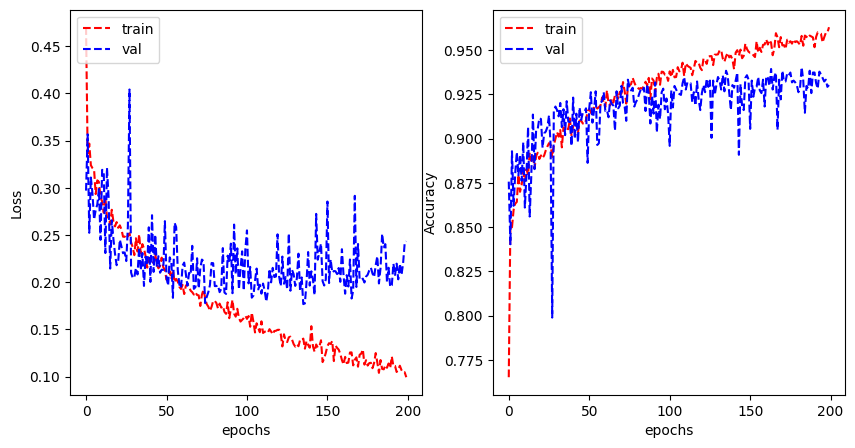


Training Swish activation model...

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1189
           1       0.91      0.90      0.90       791

    accuracy                           0.92      1980
   macro avg       0.92      0.92      0.92      1980
weighted avg       0.92      0.92      0.92      1980



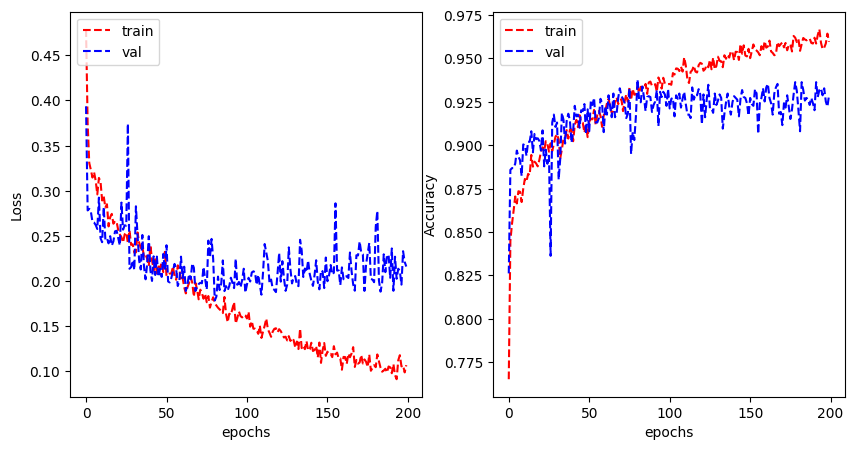

              Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0    ELU activation         1096.01                 5.48           200   
1  PReLU activation         1112.37                 5.56           200   
2  Swish activation         1107.40                 5.54           200   

   Accuracy    Loss  
0    0.9182  0.2480  
1    0.9313  0.2943  
2    0.9247  0.2313  

Training 3 Layer model...

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1189
           1       0.91      0.92      0.91       791

    accuracy                           0.93      1980
   macro avg       0.93      0.93      0.93      1980
weighted avg       0.93      0.93      0.93      1980



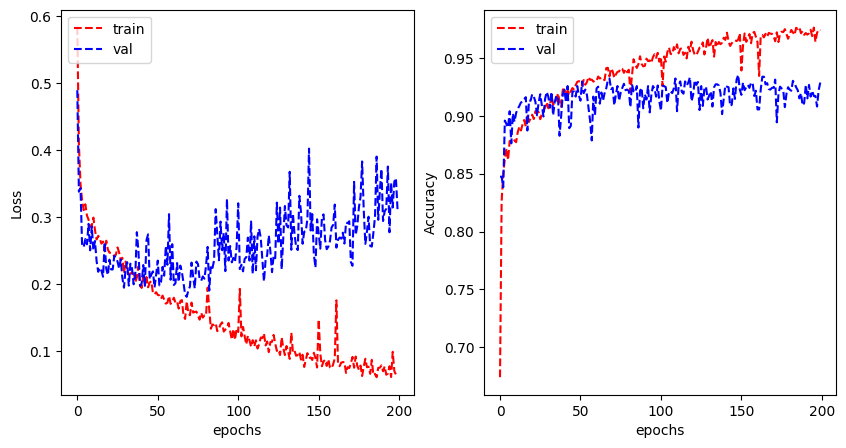


Training Simplified layers model...

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1189
           1       0.93      0.89      0.91       791

    accuracy                           0.93      1980
   macro avg       0.93      0.92      0.93      1980
weighted avg       0.93      0.93      0.93      1980



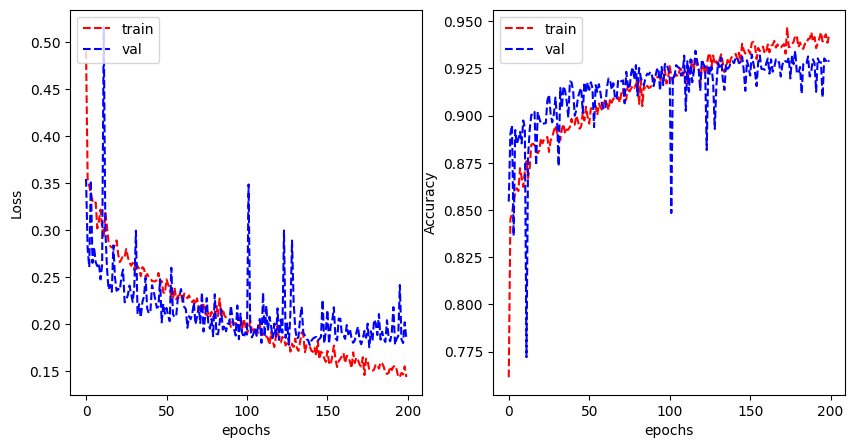


Training Regularisation model...

              precision    recall  f1-score   support

           0       0.92      0.96      0.93      1189
           1       0.93      0.87      0.90       791

    accuracy                           0.92      1980
   macro avg       0.92      0.91      0.92      1980
weighted avg       0.92      0.92      0.92      1980



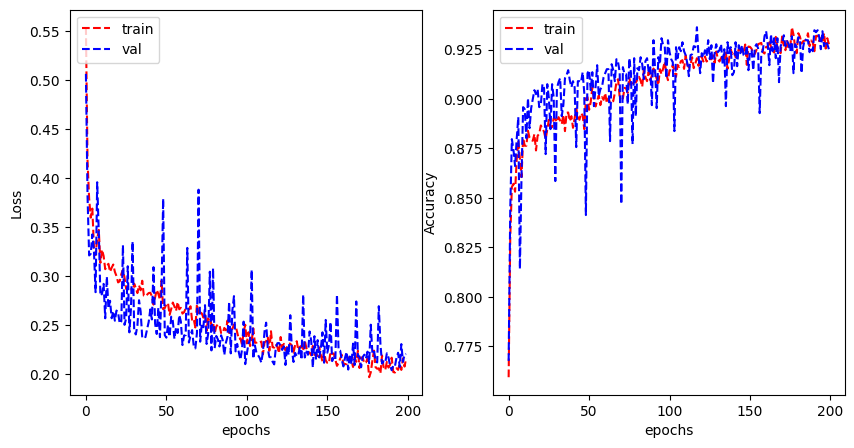


Training is cancerous early stop model...

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1189
           1       0.91      0.91      0.91       791

    accuracy                           0.93      1980
   macro avg       0.92      0.92      0.92      1980
weighted avg       0.93      0.93      0.93      1980



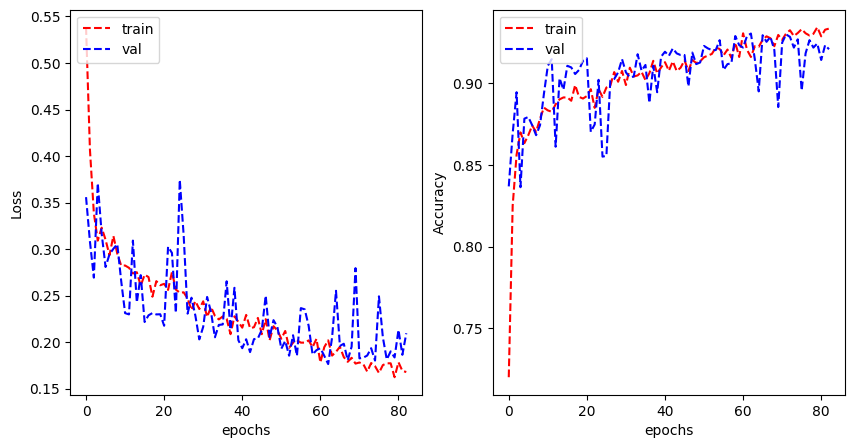

                     Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0                  3 Layer         1112.88                 5.56           200   
1        Simplified layers         1102.45                 5.51           200   
2           Regularisation         1138.70                 5.69           200   
3  is cancerous early stop          475.18                 5.73            83   

   Accuracy    Loss  
0    0.9298  0.3597  
1    0.9313  0.1977  
2    0.9202  0.2395  
3    0.9273  0.1932  


In [73]:
trained_model, history = train_and_evaluate_model(
    name="is cancerous base",
    model=isCancerousModel_base,
    train_data=isCancerous_train_data,
    val_data=isCancerous_val_data,
    test_data=isCancerous_test_data,
    loss='binary_crossentropy',
    metrics=['accuracy'],
    epochs=200,
    class_weight=isCancerous_class_weights_dict
)

df_results = pd.DataFrame(results)
print(df_results)
results = []

for model_name, builder in isCancerousModels_activation.items():
    model = builder

    trained_model, history = train_and_evaluate_model(
        name=model_name,
        model=model,
        train_data=isCancerous_train_data,
        val_data=isCancerous_val_data,
        test_data=isCancerous_test_data,
        loss='binary_crossentropy',
        metrics=['accuracy'],
        epochs=200,
        class_weight=isCancerous_class_weights_dict
    )

df_results = pd.DataFrame(results)
df_results.to_csv("is_cancer_activation_test_results.csv", index=False)
print(df_results)
results = []

for model_name, builder in isCancerousModels_structure.items():
    model = builder

    trained_model, history = train_and_evaluate_model(
        name=model_name,
        model=model,
        train_data=isCancerous_train_data,
        val_data=isCancerous_val_data,
        test_data=isCancerous_test_data,
        loss='binary_crossentropy',
        metrics=['accuracy'],
        epochs=200,
        class_weight=isCancerous_class_weights_dict
    )

trained_model, history = train_and_evaluate_model(
    name="is cancerous early stop",
    model=isCancerousModel_earlyStop,
    train_data=isCancerous_train_data,
    val_data=isCancerous_val_data,
    test_data=isCancerous_test_data,
    loss='binary_crossentropy',
    metrics=['accuracy'],
    earlyStop=[early_stop],
    epochs=200,
    class_weight=isCancerous_class_weights_dict
)

df_results = pd.DataFrame(results)
df_results.to_csv("is_cancer_structure_test_results.csv", index=False)
print(df_results)

# Cell type training


Training Cell type base model...



/home/leo/cancerAI/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


              precision    recall  f1-score   support

           0       0.94      0.89      0.91       791
           1       0.73      0.78      0.76       391
           2       0.75      0.84      0.79       496
           3       0.70      0.60      0.65       302

    accuracy                           0.81      1980
   macro avg       0.78      0.78      0.78      1980
weighted avg       0.81      0.81      0.81      1980



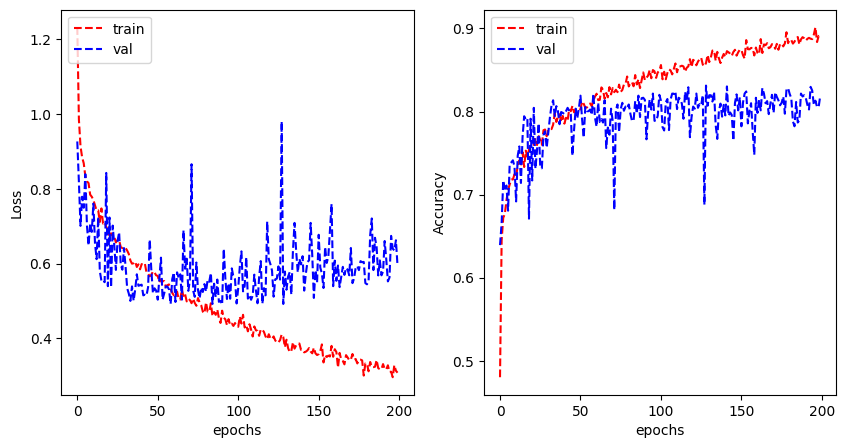

            Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0  Cell type base         1140.24                  5.7           200   

   Accuracy    Loss  
0    0.8111  0.7265  

Training ELU activation model...

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       791
           1       0.80      0.65      0.72       391
           2       0.69      0.83      0.75       496
           3       0.63      0.56      0.59       302

    accuracy                           0.78      1980
   macro avg       0.75      0.74      0.74      1980
weighted avg       0.79      0.78      0.78      1980



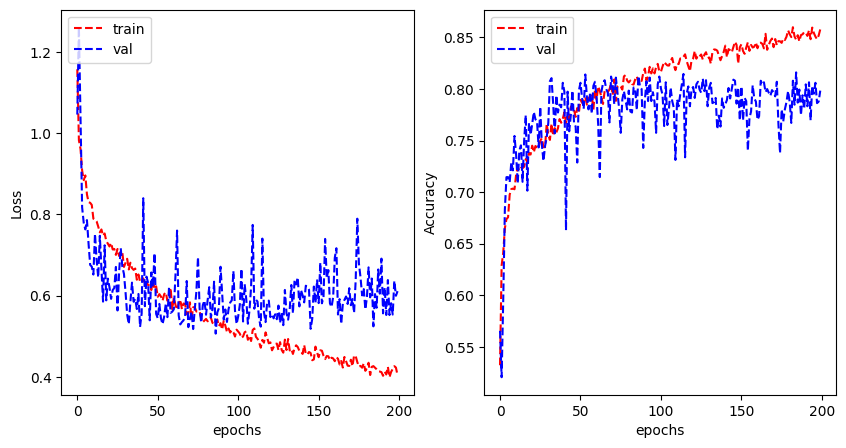


Training PReLU activation model...

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       791
           1       0.80      0.68      0.73       391
           2       0.75      0.82      0.78       496
           3       0.63      0.69      0.66       302

    accuracy                           0.80      1980
   macro avg       0.77      0.77      0.77      1980
weighted avg       0.80      0.80      0.80      1980



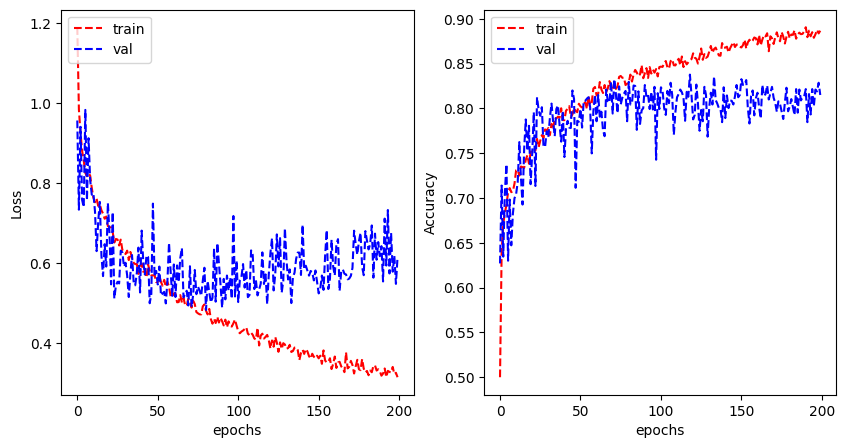


Training Swish activation model...

              precision    recall  f1-score   support

           0       0.92      0.87      0.90       791
           1       0.74      0.69      0.71       391
           2       0.74      0.82      0.78       496
           3       0.56      0.57      0.57       302

    accuracy                           0.78      1980
   macro avg       0.74      0.74      0.74      1980
weighted avg       0.78      0.78      0.78      1980



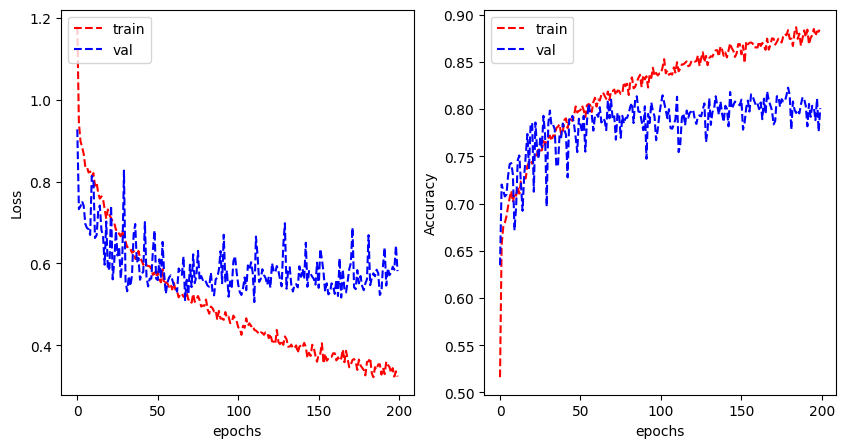

              Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0    ELU activation         1133.79                 5.67           200   
1  PReLU activation         1139.32                 5.70           200   
2  Swish activation         1128.58                 5.64           200   

   Accuracy    Loss  
0    0.7833  0.6712  
1    0.8000  0.6778  
2    0.7788  0.6888  

Training 3 Layer model...



/home/leo/cancerAI/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/leo/cancerAI/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/leo/cancerAI/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.40      1.00      0.57       791
           1       0.00      0.00      0.00       391
           2       0.00      0.00      0.00       496
           3       0.00      0.00      0.00       302

    accuracy                           0.40      1980
   macro avg       0.10      0.25      0.14      1980
weighted avg       0.16      0.40      0.23      1980



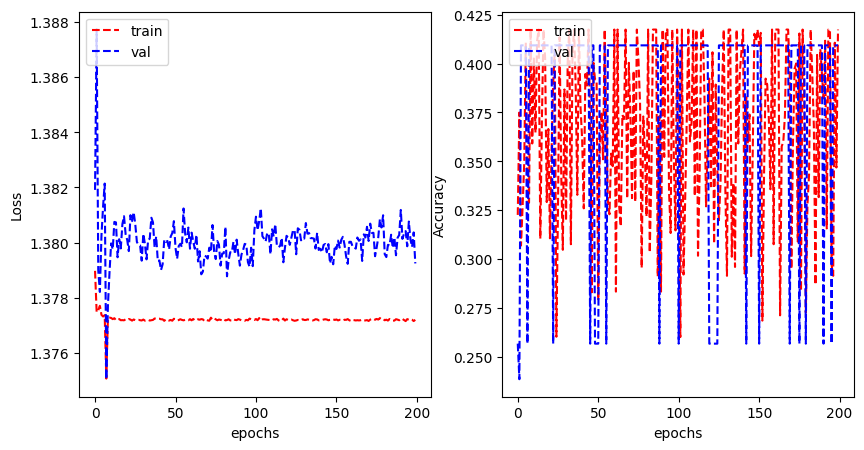


Training Simplified layers model...

              precision    recall  f1-score   support

           0       0.94      0.87      0.91       791
           1       0.73      0.76      0.75       391
           2       0.81      0.74      0.77       496
           3       0.56      0.71      0.63       302

    accuracy                           0.79      1980
   macro avg       0.76      0.77      0.76      1980
weighted avg       0.81      0.79      0.80      1980



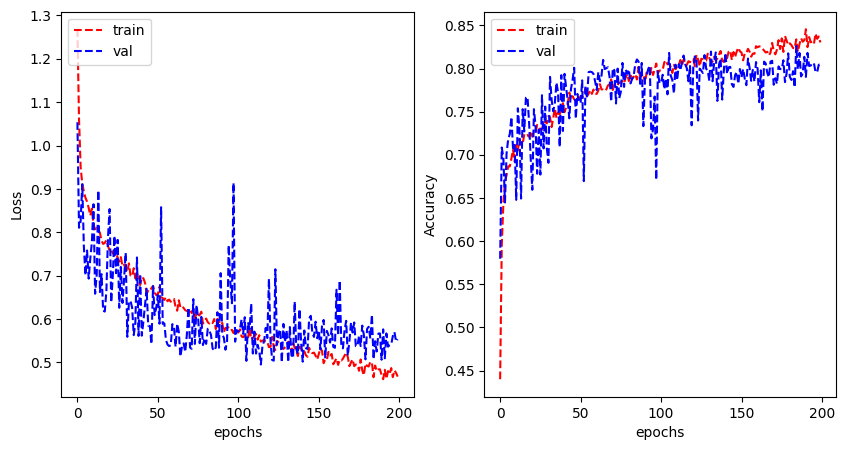


Training Regularisation model...

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       791
           1       0.81      0.56      0.66       391
           2       0.73      0.81      0.77       496
           3       0.59      0.73      0.65       302

    accuracy                           0.78      1980
   macro avg       0.76      0.75      0.75      1980
weighted avg       0.79      0.78      0.78      1980



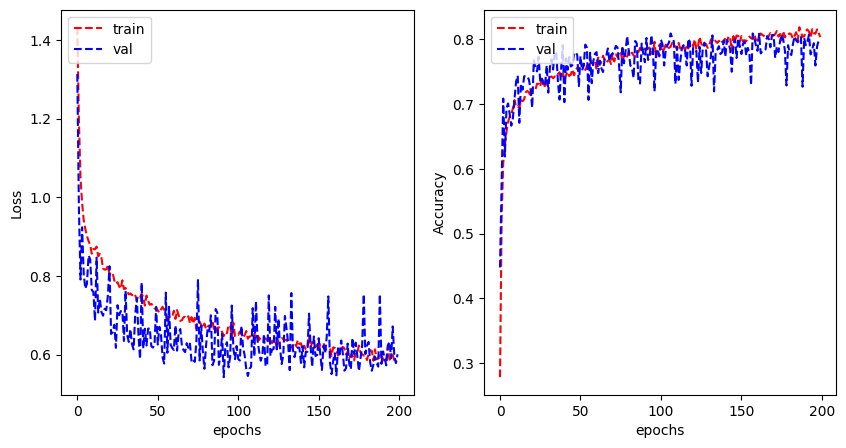


Training Cell type early stop model...

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       791
           1       0.72      0.81      0.76       391
           2       0.77      0.80      0.79       496
           3       0.69      0.58      0.63       302

    accuracy                           0.81      1980
   macro avg       0.78      0.77      0.77      1980
weighted avg       0.81      0.81      0.81      1980



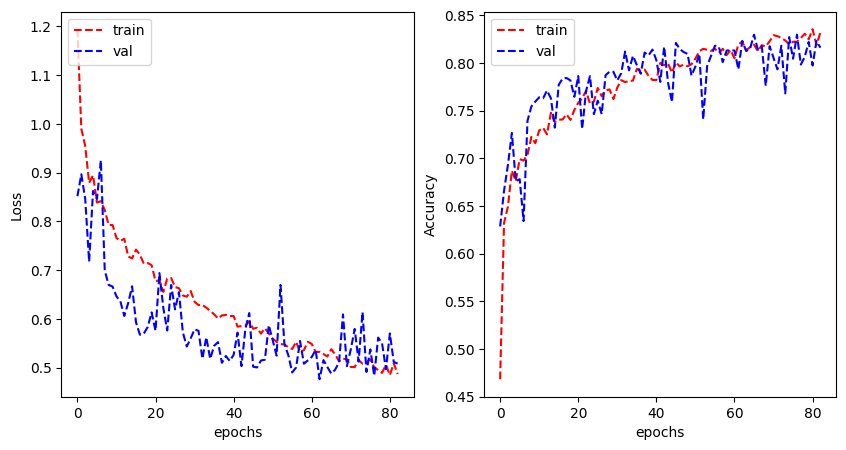

                  Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0               3 Layer         1133.52                 5.67           200   
1     Simplified layers         1115.10                 5.58           200   
2        Regularisation         1125.64                 5.63           200   
3  Cell type early stop          472.10                 5.69            83   

   Accuracy    Loss  
0    0.3995  1.3799  
1    0.7934  0.5946  
2    0.7833  0.6334  
3    0.8106  0.5315  


In [74]:

results = []
trained_model, history = train_and_evaluate_model(
    name="Cell type base",
    model=cellTypeModel_base,
    train_data=cellType_train_data,
    val_data=cellType_val_data,
    test_data=cellType_test_data,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy'],
    epochs=200,
    class_weight=cellType_class_weights_dict
)

df_results = pd.DataFrame(results)
print(df_results)
results = []

for model_name, builder in cellTypeModels_activation.items():
    model = builder

    trained_model, history = train_and_evaluate_model(
        name=model_name,
        model=model,
        train_data=cellType_train_data,
        val_data=cellType_val_data,
        test_data=cellType_test_data,
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy'],
        epochs=200,
        class_weight=cellType_class_weights_dict
    )

df_results = pd.DataFrame(results)
df_results.to_csv("cell_type_activation_test_results.csv", index=False)
print(df_results)
results = []

for model_name, builder in cellTypeModels_structure.items():
    model = builder

    trained_model, history = train_and_evaluate_model(
        name=model_name,
        model=model,
        train_data=cellType_train_data,
        val_data=cellType_val_data,
        test_data=cellType_test_data,
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy'],
        epochs=200,
        class_weight=cellType_class_weights_dict
    )

trained_model, history = train_and_evaluate_model(
        name="Cell type early stop",
        model=cellTypeModel_earlyStop,
        train_data=cellType_train_data,
        val_data=cellType_val_data,
        test_data=cellType_test_data,
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy'],
        earlyStop=[early_stop],
        epochs=200,
        class_weight=cellType_class_weights_dict
    )

df_results = pd.DataFrame(results)
df_results.to_csv("cell_type_structure_test_results.csv", index=False)
print(df_results)

**Extra data datagen**

In [75]:
dataLabels = pd.read_csv('Image_classification_data/data_labels_extraData.csv')
dataLabels['isCancerous'] = dataLabels['isCancerous'].astype(str)

train_data, test_data = train_test_split(dataLabels, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.25, random_state=42)

improved_cellType_pre_train_data = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName', 
    y_col='isCancerous',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
)


improved_cellType_pre_val_data = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName',  
    y_col='isCancerous',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
)

improved_cellType_pre_test_data = val_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory='Image_classification_data/patch_images',
    x_col='ImageName',  
    y_col='isCancerous',  
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
)

Found 6230 validated image filenames belonging to 2 classes.
Found 2077 validated image filenames belonging to 2 classes.
Found 2077 validated image filenames belonging to 2 classes.


**Is cancerous pretrain model**

In [76]:

inputs = Input(shape=(27, 27, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = MaxPooling2D(2, 2)(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(2, 2)(x)

x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
feature_output = x
final_output = Dense(1, activation='sigmoid')(feature_output)

improved_cellTypeModel_preTrain = Model(inputs=inputs, outputs=final_output)

improved_cellTypeModel_preTrain.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

improved_cellTypeModel_preTrain.fit(
        improved_cellType_pre_train_data,
        validation_data=improved_cellType_pre_val_data,
        epochs=200,
        callbacks=[early_stop],
        verbose=0
    )

improved_cellTypeModel_preTrain.evaluate(improved_cellType_pre_test_data, verbose=0)

/home/leo/cancerAI/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-05-19 02:11:39.435017: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.6 = (f32[22,32,27,27]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,3,27,27]{3,2,1,0} %bitcast.4222, f32[32,3,3,3]{3,2,1,0} %bitcast.4229, f32[32]{0} %bitcast.4697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_80_1/conv2d_320_1/convolution" source_file="/home/leo/cancerAI/lib/python3.12/site-packages/tensorflow/python/fr

[0.15785250067710876, 0.9330765604972839]

**Cell type pretrained model**


Training Cell type pre trained model...



2025-05-19 02:20:01.652178: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.6 = (f32[17,32,27,27]{3,2,1,0}, u8[0]{0}) custom-call(f32[17,3,27,27]{3,2,1,0} %bitcast.3256, f32[32,3,3,3]{3,2,1,0} %bitcast.3263, f32[32]{0} %bitcast.3265), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_80_1/functional_81_1/conv2d_320_1/convolution" source_file="/home/leo/cancerAI/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-05-19 02:20:01.662815: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] 

              precision    recall  f1-score   support

           0       0.92      0.85      0.88       791
           1       0.73      0.62      0.67       391
           2       0.70      0.79      0.75       496
           3       0.51      0.60      0.55       302

    accuracy                           0.75      1980
   macro avg       0.72      0.72      0.71      1980
weighted avg       0.76      0.75      0.76      1980



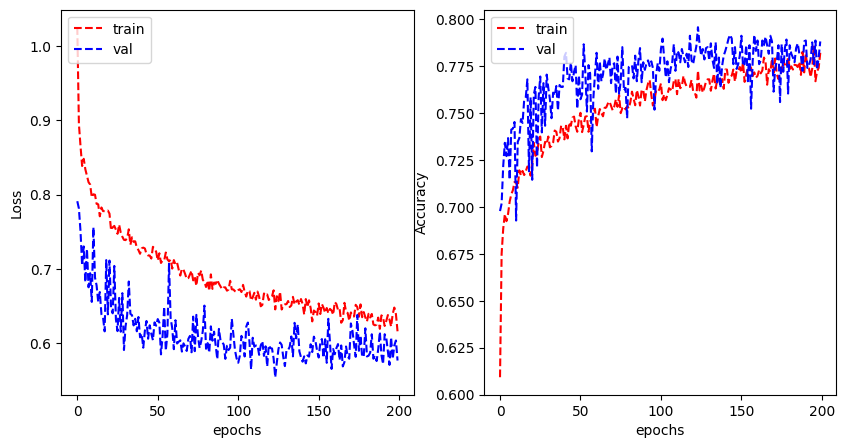

                   Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0  Cell type pre trained         1107.31                 5.54           200   

   Accuracy    Loss  
0    0.7525  0.6569  


In [77]:
improved_cellTypeModel_preTrain.trainable = False

intermediate_output_layer = improved_cellTypeModel_preTrain.layers[-3].output

improved_cellTypeModel = Model(inputs=inputs, outputs=intermediate_output_layer)

model = Sequential([
    improved_cellTypeModel,
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

improved_cellTypeModel.trainable = True

results = []
trained_model, history = train_and_evaluate_model(
    name="Cell type pre trained",
    model=model,
    train_data=cellType_train_data,
    val_data=cellType_val_data,
    test_data=cellType_test_data,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy'],
    epochs=200,
    class_weight=cellType_class_weights_dict,
)


df_results = pd.DataFrame(results)
print(df_results)




# Judgement


**Results**


**is cancerous**

Different activation functions had minimal impact on overall performance. Accuracy varied slightly across models, but results were more influenced by test data than by the choice of activation. On average, ReLU performed best with an accuracy around 0.93 and the lowest loss at approximately 0.21. ELU performed slightly worse with 0.92 accuracy and a 0.25 loss. PReLU had the highest accuracy (0.94) but also the highest loss (0.29), while Swish performed in between.


Although PReLU was slightly more accurate, its high loss makes it less reliable for a task as important as cancer detection. Misclassifying cancerous cells can have serious ethical consequences, so loss (which measures confidence and precision) must be kept low. Therefore, ReLU is the most appropriate choice for this task.


Adding a third layer did not improve accuracy and increased loss significantly. Simplifying the architecture maintained accuracy and lowered loss to around 0.20. Regularization had minimal effect, likely because overfitting wasn't a major issue. Early stopping slightly lowered loss, likely due to early stopping restoring best weights instead of using the final model generated.


**Optimal is cancerous model**


judging by these results, the optimal model uses ReLU activation, two simplified layers, and early stopping. This combination offers the best balance of accuracy and loss, while training efficiently.


**cell type**

Activation functions impacted performance slightly more in this task. ReLU produced the highest accuracy at around 0.81 but had the highest loss at around 0.73, this is due to overfitting. ELU had lower accuracy at around 0.78 but also the lowest loss at around 0.67, indicating more stable generalization. PReLU balanced both metrics well, with 0.80 accuracy and 0.68 loss. Swish again performed in the middle.


Adding an extra layer caused the model to fail completely. Simplifying the model reduced overfitting and improved loss to about 0.59. Regularization reduced overfitting but slightly hurt performance. Early stopping was the most effective solution, reducing loss to 0.53 while maintaining accuracy, this performance is due to it reducing overfitting and restoring best weights

**Cell type with pretraining**

Pretraining on the “is cancerous” task did not improve results. While performance was similar to other models, it slightly underperformed, possibly because cancer classification is too dissimilar to cell type classification.


**Optimal Cell type model**


The ideal cell type model uses PReLU activation with early stopping. This setup offers a strong balance between accuracy and stability.


# Evaluation


**Comparison**


Paper 1: Appendix 1


This paper uses a similar dataset, with the key difference being that it works with larger images containing many cells.. Unlike my approach and the previous paper, this model uses a more complex dual-branch CNN with a feature aggregation module and a context encoding module. The feature aggregation module uses two full residual convolutional networks (FRCNs) on different image resolutions. These are fused through convolutional layers to capture spatial relationships. The context encoding module then extracts global features for nucleus classification.


This architecture is highly effective for detecting patterns across large, high-resolution images. However, it’s less suited for small images like the ones in my dataset, where spatial relationships are minimal and each image contains a single, centered cell. My CNN-based approach is simpler and better suited for the data provided.


Paper 2: Appendix 2


This paper also uses the same dataset and performs a two-stage task: cell detection with U-Net segmentation followed by classification using a CNN. While this is a powerful approach for working with large and complex images, my dataset’s simplicity makes U-Net unnecessary. Since each image already contains one isolated cell, classification can be done directly.


Their classification model achieved an accuracy of 0.78, which is similar to my results, indicating that CNNs alone are sufficient for this task when detection is not required.


# Ultimate judgement


I wasn’t able to find any prior work that directly addressed the task of binary “is cancerous” classification, so a direct comparison is not possible. However, my model achieved high accuracy, approaching 95%, and a low loss around 0.2. In a real-world context, this could be used as a fast screening tool to flag potentially cancerous cells for further review.


That said, cancer detection is an ethically sensitive task, where false positives and false negatives have serious consequences. If this model were to be deployed, it would need to be trained and tested on much more data, and should also be used alongside other diagnostic methods.


As for cell type classification, my model performed similarly to those in existing literature. Since all models use CNNs and achieved similar scores, it is unlikely that significant improvements can be made using a CNN.


While my results are strong for this dataset, especially considering its size and simplicity, further improvements would be necessary for any real-world medical deployment, particularly in ensuring robustness and reducing risks of misclassification.




# Final models and reaults


Training is cancerous final model...

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1189
           1       0.90      0.91      0.91       791

    accuracy                           0.92      1980
   macro avg       0.92      0.92      0.92      1980
weighted avg       0.92      0.92      0.92      1980



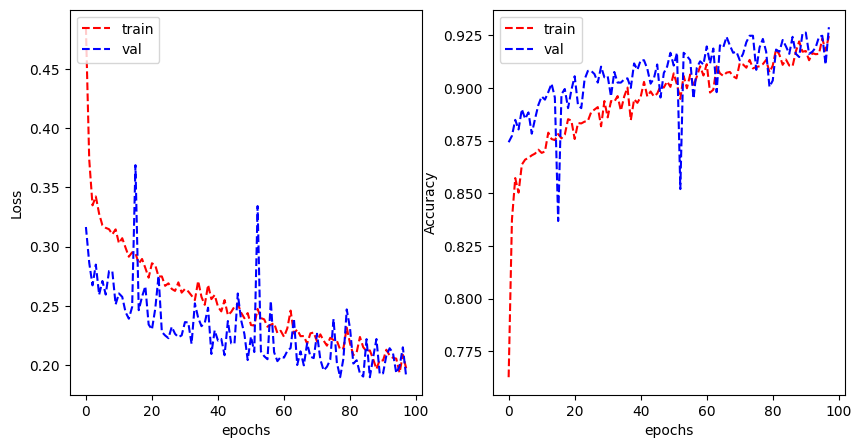

                Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0  is cancerous final          551.95                 5.63            98   

   Accuracy    Loss  
0    0.9247  0.2033  

Training Cell type final model...



/home/leo/cancerAI/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


              precision    recall  f1-score   support

           0       0.85      0.93      0.89       791
           1       0.74      0.76      0.75       391
           2       0.76      0.77      0.77       496
           3       0.69      0.48      0.57       302

    accuracy                           0.79      1980
   macro avg       0.76      0.74      0.74      1980
weighted avg       0.78      0.79      0.78      1980



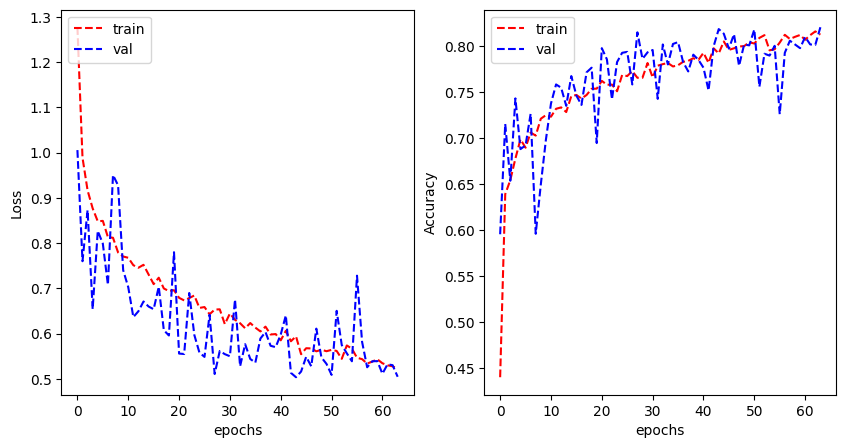

             Model  Total Time (s)  Avg Epoch  Time (s)  Total Epochs  \
0  Cell type final          366.05                 5.72            64   

   Accuracy    Loss  
0    0.7889  0.5441  


In [80]:
isCancerousModel_final = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(27, 27, 3)),
    MaxPooling2D(2, 2),
            
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

results = []
trained_model, history = train_and_evaluate_model(
    name="is cancerous final",
    model=isCancerousModel_final,
    train_data=isCancerous_train_data,
    val_data=isCancerous_val_data,
    test_data=isCancerous_test_data,
    loss='binary_crossentropy',
    metrics=['accuracy'],
    epochs=200,
    class_weight=isCancerous_class_weights_dict,
    earlyStop=[early_stop]
)


df_results = pd.DataFrame(results)
print(df_results)

cellTypeModel_final = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(27, 27, 3)),
    PReLU(alpha_initializer='zeros'),
    
    Conv2D(32, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),

    Conv2D(64, (3, 3), padding='same'),
    PReLU(alpha_initializer='zeros'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64),
    PReLU(alpha_initializer='zeros'),
    
    Dense(4, activation='softmax')
])

results = []
trained_model, history = train_and_evaluate_model(
    name="Cell type final",
    model=cellTypeModel_final,
    train_data=cellType_train_data,
    val_data=cellType_val_data,
    test_data=cellType_test_data,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy'],
    epochs=200,
    class_weight=cellType_class_weights_dict,
    earlyStop=[early_stop]
)


df_results = pd.DataFrame(results)
print(df_results)


# Appendix

1. Tian Bai, Jiayu Xu, Zhenting Zhang, Shuyu Guo, Xiao Luo, Context-aware learning for cancer cell nucleus recognition in pathology images, Bioinformatics, Volume 38, Issue 10, May 2022, Pages 2892–2898, https://doi.org/10.1093/bioinformatics/btac167

2. Gates, Quinn D. and Allali, Mohamed and Martin-King, Chloe, 'Detection and Classification of Cells in Colorectal Histology Images Utilizing U-Net Machine Learning Architecture'. Available at SSRN: https://ssrn.com/abstract=3981501 or http://dx.doi.org/10.2139/ssrn.3981501